# CONFIG

In [3]:
import os

print(os.getcwd())
if not os.getcwd().endswith("app"):
    os.chdir("../app")
    print(os.getcwd())

from maikol_utils.print_utils import print_separator
import matplotlib.pyplot as plt
import numpy as np
import cv2



%load_ext autoreload
%autoreload 2
%matplotlib inline

/home/turbotowerlnx/Documents/Master/BIOM/notebooks
/home/turbotowerlnx/Documents/Master/BIOM/app
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
from src.config import Configuration

CONFIG = Configuration(
    crop_size=24,
    stride=1
)

# CODE

## Data

In [15]:
from maikol_utils.file_utils import list_dir_files

rng = np.random.default_rng(CONFIG.seed)

img_paths, n = list_dir_files(CONFIG.wider_path, recursive=True)
print(f"Found {n} files in {CONFIG.wider_path}")

Found 12880 files in ../data/others/WIDER_train/images


In [16]:
from src.model.haar_cascade_parser import HaarCascadeParser, load_cascade

# Load and parse the cascade
cascade_path = os.path.join(CONFIG.haar_cascades, 'haarcascade_frontalface_default.xml')
# cascade_path = os.path.join(CONFIG.haar_cascades, 'haarcascade_frontalcatface.xml')
cascade = load_cascade(cascade_path)

CONFIG.crop_size = max(cascade.height, cascade.width)

parser = HaarCascadeParser(cascade_path)
parser.print_summary(cascade)

Loading Haar cascade from: ../models/haar_cascades/haarcascade_frontalface_default.xml

Haar Cascade Summary
Type: opencv-haar-classifier
Feature Type: HAAR
Size: 24x24
Total Stages: 25
Total Features: 211



## Construct class from parser

In [17]:
from src.model import CascadeClassifier
classifier = CascadeClassifier(CONFIG, cascade)

In [18]:
print(img_paths[0])
# img_path = "data/others/WIDER_train/images/0--Parade/0_Parade_marchingband_1_13.jpg"
# img_path = "data/others/WIDER_train/images/20--Family_Group/20_Family_Group_Family_Group_20_11.jpg"
# img_path = "data/others/WIDER_train/images/9--Press_Conference/9_Press_Conference_Press_Conference_9_71.jpg"
img_path = "../data/others/image2.png"

from cv2 import imread
img = imread(img_path, cv2.IMREAD_GRAYSCALE)
# Convert grayscale to BGR for colored rectangle drawing
img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)


../data/others/WIDER_train/images/0--Parade/0_Parade_Parade_0_3.jpg


In [19]:
faces = classifier.predict(img_path=img_path)
len(faces)

9

In [20]:
faces

[{'x': 248, 'y': 363, 'w': 24, 'h': 24},
 {'x': 190, 'y': 604, 'w': 24, 'h': 24},
 {'x': 304, 'y': 610, 'w': 24, 'h': 24},
 {'x': 27, 'y': 123, 'w': 59, 'h': 59},
 {'x': 106, 'y': 135, 'w': 63, 'h': 63},
 {'x': 158, 'y': 334, 'w': 46, 'h': 46},
 {'x': 490, 'y': 69, 'w': 74, 'h': 74},
 {'x': 318, 'y': 110, 'w': 66, 'h': 66},
 {'x': 206, 'y': 115, 'w': 66, 'h': 66}]

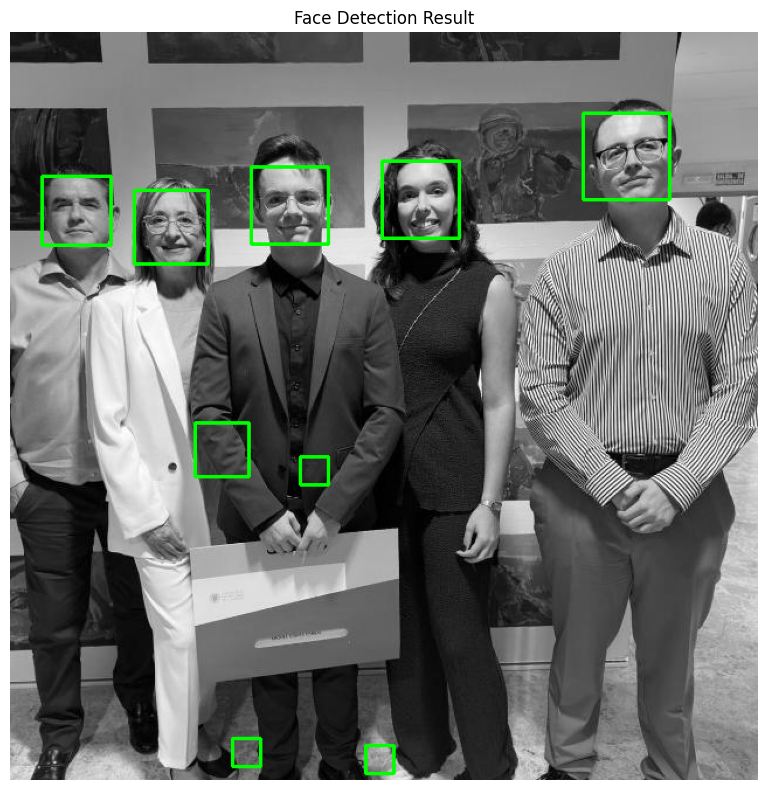

In [21]:
def draw_boxes(img, faces):
    for crop in faces:
        x, y, w, h = crop['x'], crop['y'], crop['w'], crop['h']
        # img, pt1, pt2, color (BGR), thickness
        cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)
    return img

boxes = draw_boxes(img.copy(), faces)

plt.figure(figsize=(12, 8))
# Convert BGR to RGB for matplotlib display (remove grayscale colormap)
plt.imshow(cv2.cvtColor(boxes, cv2.COLOR_BGR2RGB))
plt.title('Face Detection Result')
plt.axis('off')
plt.tight_layout()
plt.show()

In [9]:
from src.data.crops import get_all_image_crops
crops = get_all_image_crops(
    CONFIG, 
    img_path=img_path
)
len(crops)

124963

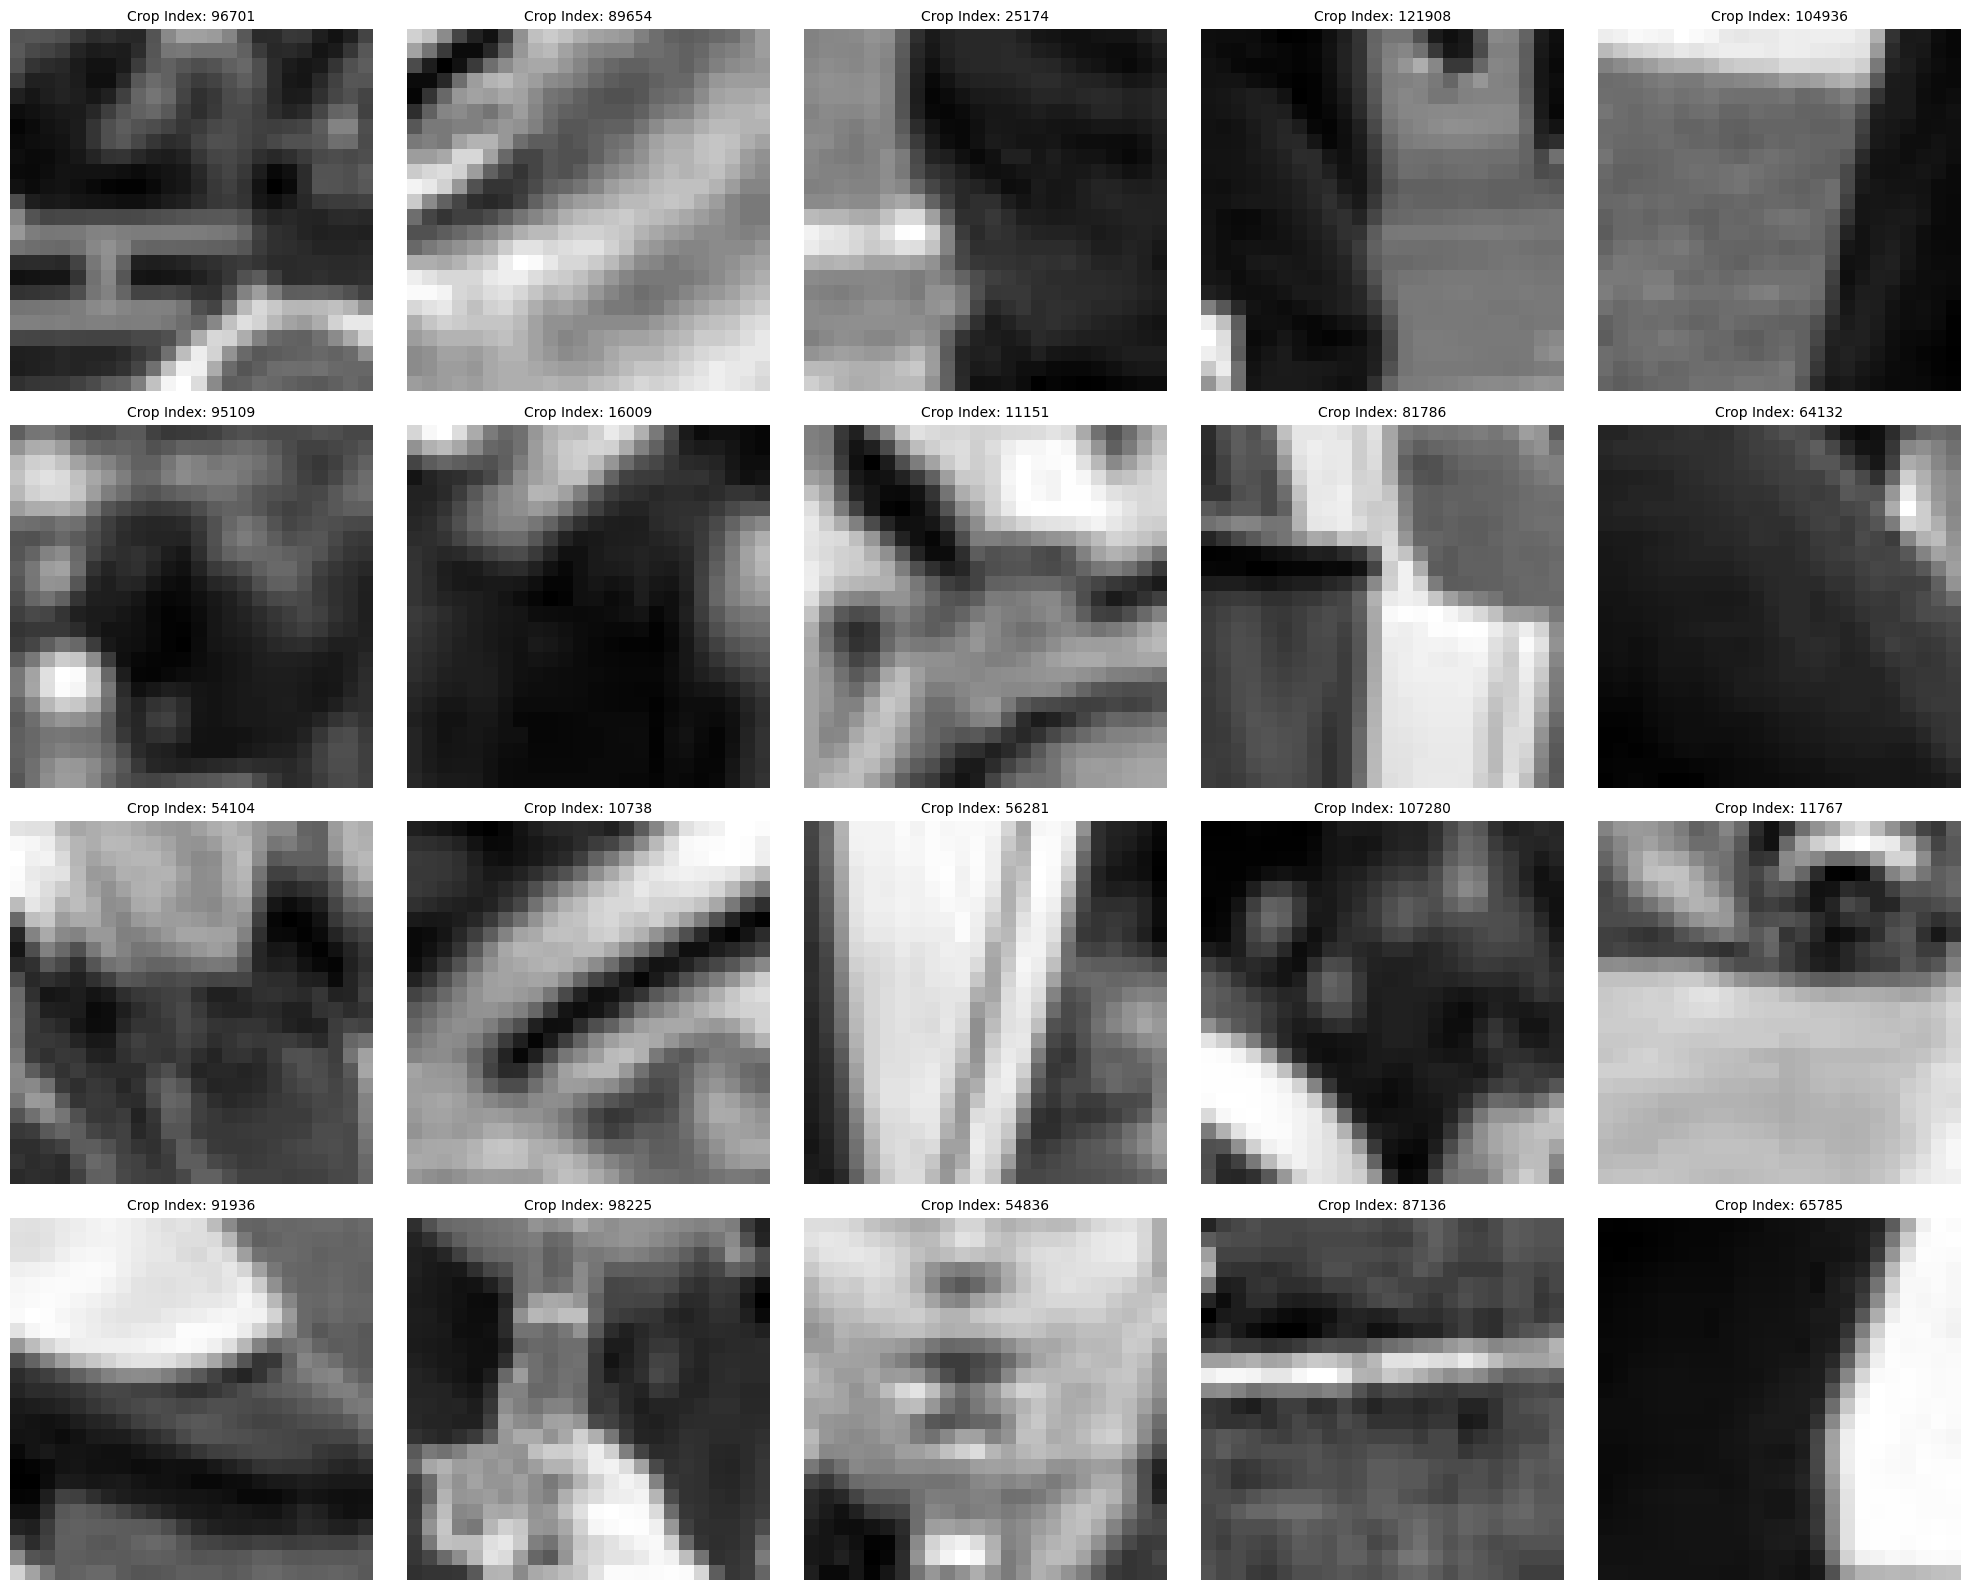

In [10]:
from PIL import Image
# Get random indices instead of random crops
sample_indices = rng.choice(len(crops), size=20, replace=False)
sample = [crops[i] for i in sample_indices]

def show_images(images, indices):
    fig, axes = plt.subplots(4, 5, figsize=(20, 16))
    for ax, img, crop_idx in zip(axes.flatten(), images, indices):
        ax.imshow(img, cmap='gray')
        ax.set_title(f'Crop Index: {crop_idx}', fontsize=10)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_images([i['img'] for i in sample], sample_indices)

In [38]:
import cv2

face_img = cv2.imread("data/ViolaJones/face_images/11.jpg", cv2.IMREAD_GRAYSCALE)

# scale to 24x24
face_img = cv2.resize(face_img, (24, 24))

In [39]:
face_img.shape

(24, 24)

In [40]:
# result = classifier._predict_crop(crops[79848]['img'])
# result = classifier._predict_crop(crops[11876]['img'])
result = classifier._predict_crop(face_img)

result

True

# Print the parser

In [14]:
parser.print_stages_summary(cascade)


Stages Summary

Stage 0:
  Threshold: -5.0425500870
  Weak Classifiers: 9
  Max Count: 9
    WeakClassifier(0): Feature 0, threshold=-0.031512, left=2.087538, right=-2.217210
    WeakClassifier(1): Feature 1, threshold=0.012396, left=-1.863394, right=1.327205
    WeakClassifier(2): Feature 2, threshold=0.021928, left=-1.510525, right=1.062573
    WeakClassifier(3): Feature 3, threshold=0.005753, left=-0.874639, right=1.176034
    WeakClassifier(4): Feature 4, threshold=0.015014, left=-0.779457, right=1.260842
    ... and 4 more

Stage 1:
  Threshold: -4.9842400551
  Weak Classifiers: 16
  Max Count: 16
    WeakClassifier(0): Feature 9, threshold=-0.021110, left=1.243565, right=-1.571301
    WeakClassifier(1): Feature 10, threshold=0.020356, left=-1.620478, right=1.181776
    WeakClassifier(2): Feature 11, threshold=0.021309, left=-1.941593, right=0.700691
    WeakClassifier(3): Feature 12, threshold=0.091660, left=-0.556701, right=1.728442
    WeakClassifier(4): Feature 13, threshold=

In [15]:
parser.print_features_summary(cascade)


Features Summary

Feature 0:
  Rect(x=6, y=4, w=12, h=9, weight=-1.0)
  Rect(x=6, y=7, w=12, h=3, weight=3.0)

Feature 1:
  Rect(x=6, y=4, w=12, h=7, weight=-1.0)
  Rect(x=10, y=4, w=4, h=7, weight=3.0)

Feature 2:
  Rect(x=3, y=9, w=18, h=9, weight=-1.0)
  Rect(x=3, y=12, w=18, h=3, weight=3.0)

Feature 3:
  Rect(x=8, y=18, w=9, h=6, weight=-1.0)
  Rect(x=8, y=20, w=9, h=2, weight=3.0)

Feature 4:
  Rect(x=3, y=5, w=4, h=19, weight=-1.0)
  Rect(x=5, y=5, w=2, h=19, weight=2.0)

Feature 5:
  Rect(x=6, y=5, w=12, h=16, weight=-1.0)
  Rect(x=6, y=13, w=12, h=8, weight=2.0)

Feature 6:
  Rect(x=5, y=8, w=12, h=6, weight=-1.0)
  Rect(x=5, y=11, w=12, h=3, weight=2.0)

Feature 7:
  Rect(x=11, y=14, w=4, h=10, weight=-1.0)
  Rect(x=11, y=19, w=4, h=5, weight=2.0)

Feature 8:
  Rect(x=4, y=0, w=7, h=6, weight=-1.0)
  Rect(x=4, y=3, w=7, h=3, weight=2.0)

Feature 9:
  Rect(x=6, y=6, w=12, h=6, weight=-1.0)
  Rect(x=6, y=8, w=12, h=2, weight=3.0)

... and 2903 more features


## Access Cascade Data Programmatically

In [16]:
# Access specific stage
stage_idx = 0
stage = cascade.stages[stage_idx]

print(f"Stage {stage_idx}:")
print(f"  Threshold: {stage.threshold}")
print(f"  Number of weak classifiers: {len(stage.weak_classifiers)}")
print()

# Access weak classifiers in that stage
for clf in stage.weak_classifiers[:3]:
    print(f"Weak Classifier {clf.classifier_id}:")
    print(f"  Feature ID: {clf.feature_id}")
    print(f"  Classifier Threshold: {clf.threshold:.10f}")
    print(f"  Left Value:  {clf.left_value:.10f}")
    print(f"  Right Value: {clf.right_value:.10f}")
    
    # Access the actual feature
    if clf.feature is not None:
        print(f"  Feature has {len(clf.feature.rectangles)} rectangles:")
        for rect in clf.feature.rectangles:
            print(f"    {rect}")
    print()

Stage 0:
  Threshold: -5.042550086975098
  Number of weak classifiers: 9

Weak Classifier 0:
  Feature ID: 0
  Classifier Threshold: -0.0315119997
  Left Value:  2.0875380039
  Right Value: -2.2172100544
  Feature has 2 rectangles:
    Rect(x=6, y=4, w=12, h=9, weight=-1.0)
    Rect(x=6, y=7, w=12, h=3, weight=3.0)

Weak Classifier 1:
  Feature ID: 1
  Classifier Threshold: 0.0123960003
  Left Value:  -1.8633940220
  Right Value: 1.3272049427
  Feature has 2 rectangles:
    Rect(x=6, y=4, w=12, h=7, weight=-1.0)
    Rect(x=10, y=4, w=4, h=7, weight=3.0)

Weak Classifier 2:
  Feature ID: 2
  Classifier Threshold: 0.0219279993
  Left Value:  -1.5105249882
  Right Value: 1.0625729561
  Feature has 2 rectangles:
    Rect(x=3, y=9, w=18, h=9, weight=-1.0)
    Rect(x=3, y=12, w=18, h=3, weight=3.0)



In [17]:
# Create DataFrame with all weak classifiers from all stages
classifiers_data = []
for stage in cascade.stages:
    for clf in stage.weak_classifiers:
        classifiers_data.append({
            'stage': stage.stage_id,
            'stage_threshold': stage.threshold,
            'classifier_id': clf.classifier_id,
            'feature_id': clf.feature_id,
            'classifier_threshold': clf.threshold,
            'left_value': clf.left_value,
            'right_value': clf.right_value,
            'num_rects': len(clf.feature.rectangles) if clf.feature else 0
        })

df_classifiers = pd.DataFrame(classifiers_data)
print(f"Total weak classifiers: {len(df_classifiers)}")
print(f"\nFirst 10 classifiers:")
print(df_classifiers.head(10))

Total weak classifiers: 2913

First 10 classifiers:
   stage  stage_threshold  classifier_id  feature_id  classifier_threshold  \
0      0         -5.04255              0           0             -0.031512   
1      0         -5.04255              1           1              0.012396   
2      0         -5.04255              2           2              0.021928   
3      0         -5.04255              3           3              0.005753   
4      0         -5.04255              4           4              0.015014   
5      0         -5.04255              5           5              0.099371   
6      0         -5.04255              6           6              0.002734   
7      0         -5.04255              7           7             -0.018859   
8      0         -5.04255              8           8              0.005974   
9      1         -4.98424              0           9             -0.021110   

   left_value  right_value  num_rects  
0    2.087538    -2.217210          2  
1   -1.86

In [18]:
# Example: Extract all rectangles from all features
features_data = []
for feat_id, feature in cascade.features.items():
    for rect_idx, rect in enumerate(feature.rectangles):
        features_data.append({
            'feature_id': feat_id,
            'rect_index': rect_idx,
            'x': rect.x,
            'y': rect.y,
            'width': rect.width,
            'height': rect.height,
            'weight': rect.weight
        })

df_features = pd.DataFrame(features_data)
print(f"Total rectangles across all features: {len(df_features)}")
print(f"\nFirst 15 rectangles:")
print(df_features.head(15))

Total rectangles across all features: 6383

First 15 rectangles:
    feature_id  rect_index   x   y  width  height  weight
0            0           0   6   4     12       9    -1.0
1            0           1   6   7     12       3     3.0
2            1           0   6   4     12       7    -1.0
3            1           1  10   4      4       7     3.0
4            2           0   3   9     18       9    -1.0
5            2           1   3  12     18       3     3.0
6            3           0   8  18      9       6    -1.0
7            3           1   8  20      9       2     3.0
8            4           0   3   5      4      19    -1.0
9            4           1   5   5      2      19     2.0
10           5           0   6   5     12      16    -1.0
11           5           1   6  13     12       8     2.0
12           6           0   5   8     12       6    -1.0
13           6           1   5  11     12       3     2.0
14           7           0  11  14      4      10    -1.0
